# Credit Scoring

## Библиотеки

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

In [31]:
RANDOM_STATE = 2004

## Обзор датасетов

In [33]:
apps = pd.read_csv("datasets/application_record.csv")

### Application record

In [34]:
apps.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [35]:
print("Duplicate: ", apps["ID"].duplicated().sum())
print("NaN: ", apps["OCCUPATION_TYPE"].isna().sum())  # because only here do we have NaN

Duplicate:  47
NaN:  134203


### Credit record

In [36]:
cred = pd.read_csv("datasets/credit_record.csv")
cred

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


## Preprocessing datasets

### Column renaming dictionary

In [37]:
rename_a = {
    "CODE_GENDER": "gender",
    "FLAG_OWN_CAR": "f_car",
    "FLAG_OWN_REALTY": "f_realty",
    "CNT_CHILDREN": "cnt_children",
    "AMT_INCOME_TOTAL": "total_income",
    "NAME_INCOME_TYPE": "income_type",
    "NAME_EDUCATION_TYPE": "education",
    "NAME_FAMILY_STATUS": "family_status",
    "NAME_HOUSING_TYPE": "housing",
    "DAYS_BIRTH": "birthday",
    "DAYS_EMPLOYED": "employment_days",
    "FLAG_MOBIL": "f_mobile",
    "FLAG_WORK_PHONE": "f_work_phone",
    "FLAG_PHONE": "f_phone",
    "FLAG_EMAIL": "f_email",
    "OCCUPATION_TYPE": "occupation",
    "CNT_FAM_MEMBERS": "cnt_fam_members",
}

rename_c = {
    "MONTHS_BALANCE": "month",
    "STATUS": "status"
}

### Preprocessing application

In [38]:
apps.rename(columns=rename_a, inplace=True)
apps.drop_duplicates("ID", inplace=True)

apps["age"] = (-apps["birthday"] / 365).astype(int)
apps["employment_years"] = apps["employment_days"].apply(
    lambda x: float(-x / 365) if pd.notnull(x) and x < 0 else 0)

apps["gender"] = apps["gender"].apply(lambda x: 1 if x == "M" else 0)
apps["f_car"] = apps["f_car"].apply(lambda x: 1 if x == "Y" else 0)
apps["f_realty"] = apps["f_realty"].apply(lambda x: 1 if x == "Y" else 0)
apps["cnt_fam_members"] = apps["cnt_children"].astype(int)
apps["employment_years"] = apps["employment_years"].round(1)
apps.drop(columns=["birthday", "employment_days"], inplace=True)

In [39]:
apps

,ID,gender,f_car,f_realty,cnt_children,total_income,income_type,education,family_status,housing,f_mobile,f_work_phone,f_phone,f_email,occupation,cnt_fam_members,age,employment_years
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,0,32,12.4
1,5008805,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,0,32,12.4
2,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,0,58,3.1
3,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4
4,5008809,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,1,0,1,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,1,0,0,0,NaN,0,62,0.0
438553,6840222,0,0,0,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,1,0,0,0,Laborers,0,43,8.2
438554,6841878,0,0,0,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,1,1,0,0,Sales staff,0,22,1.0
438555,6842765,0,0,1,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,1,0,0,0,NaN,0,59,0.0


In [40]:
apps.describe()

,ID,gender,f_car,f_realty,cnt_children,total_income,f_mobile,f_work_phone,f_phone,f_email,cnt_fam_members,age,employment_years
count,4.385100e+05,438510.000000,438510.000000,438510.000000,438510.000000,4.385100e+05,438510.0,438510.000000,438510.000000,438510.000000,438510.000000,438510.000000,438510.000000
mean,6.022035e+06,0.328622,0.371903,0.693348,0.427381,1.875254e+05,1.0,0.206128,0.287770,0.108200,0.427381,43.326816,5.952266
std,5.714962e+05,0.469713,0.483313,0.461104,0.724874,1.100893e+05,0.0,0.404524,0.452724,0.310634,0.724874,11.467466,6.568634
min,5.008804e+06,0.000000,0.000000,0.000000,0.000000,2.610000e+04,1.0,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,5.609362e+06,0.000000,0.000000,0.000000,0.000000,1.215000e+05,1.0,0.000000,0.000000,0.000000,0.000000,34.000000,1.000000
50%,6.047720e+06,0.000000,0.000000,1.000000,0.000000,1.609402e+05,1.0,0.000000,0.000000,0.000000,0.000000,42.000000,4.000000
75%,6.454161e+06,1.000000,1.000000,1.000000,1.000000,2.250000e+05,1.0,0.000000,1.000000,0.000000,1.000000,53.000000,8.500000
max,7.999952e+06,1.000000,1.000000,1.000000,19.000000,6.750000e+06,1.0,1.000000,1.000000,1.000000,19.000000,69.000000,48.000000


#### Filling in the blanks in `occupation`

In [41]:
apps_with_occ = apps[apps["occupation"].notna()].copy()
apps_no_occ = apps[apps["occupation"].isna()].copy()

In [42]:
X = apps_with_occ.drop(columns=["ID", "occupation"])
y = apps_with_occ["occupation"]

In [43]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=RANDOM_STATE)

model_occ = RandomForestClassifier(random_state=RANDOM_STATE)
model_occ.fit(X_train, y_train)

y_pred = model_occ.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.956142656852436


In [45]:
X_missing = pd.get_dummies(apps_no_occ.drop(columns=["ID", "occupation"]), drop_first=True)
X_missing = X_missing.reindex(columns=X_encoded.columns, fill_value=0)

In [46]:
apps_no_occ["occupation"] = model_occ.predict(X_missing)

In [47]:
apps = pd.concat([apps_with_occ, apps_no_occ]).sort_values("ID").reset_index(drop=True)

In [48]:
apps

,ID,gender,f_car,f_realty,cnt_children,total_income,income_type,education,family_status,housing,f_mobile,f_work_phone,f_phone,f_email,occupation,cnt_fam_members,age,employment_years
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Managers,0,32,12.4
1,5008805,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Managers,0,32,12.4
2,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,0,58,3.1
3,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4
4,5008809,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438505,7999660,0,0,0,0,90000.0,State servant,Higher education,Single / not married,House / apartment,1,0,0,0,Core staff,0,36,14.9
438506,7999696,0,0,1,2,135000.0,State servant,Secondary / secondary special,Married,House / apartment,1,0,0,0,Medicine staff,2,34,12.0
438507,7999738,1,0,1,0,180000.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Core staff,0,27,0.3
438508,7999784,0,1,1,1,180000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,1,0,0,0,Sales staff,1,29,1.2


#### Checking of emissions

In [49]:
apps.describe()

,ID,gender,f_car,f_realty,cnt_children,total_income,f_mobile,f_work_phone,f_phone,f_email,cnt_fam_members,age,employment_years
count,4.385100e+05,438510.000000,438510.000000,438510.000000,438510.000000,4.385100e+05,438510.0,438510.000000,438510.000000,438510.000000,438510.000000,438510.000000,438510.000000
mean,6.022035e+06,0.328622,0.371903,0.693348,0.427381,1.875254e+05,1.0,0.206128,0.287770,0.108200,0.427381,43.326816,5.952266
std,5.714962e+05,0.469713,0.483313,0.461104,0.724874,1.100893e+05,0.0,0.404524,0.452724,0.310634,0.724874,11.467466,6.568634
min,5.008804e+06,0.000000,0.000000,0.000000,0.000000,2.610000e+04,1.0,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,5.609362e+06,0.000000,0.000000,0.000000,0.000000,1.215000e+05,1.0,0.000000,0.000000,0.000000,0.000000,34.000000,1.000000
50%,6.047720e+06,0.000000,0.000000,1.000000,0.000000,1.609402e+05,1.0,0.000000,0.000000,0.000000,0.000000,42.000000,4.000000
75%,6.454161e+06,1.000000,1.000000,1.000000,1.000000,2.250000e+05,1.0,0.000000,1.000000,0.000000,1.000000,53.000000,8.500000
max,7.999952e+06,1.000000,1.000000,1.000000,19.000000,6.750000e+06,1.0,1.000000,1.000000,1.000000,19.000000,69.000000,48.000000


In [50]:
col_children = "cnt_children"
Q1_children = apps[col_children].quantile(0.25)
Q3_children = apps[col_children].quantile(0.75)
IQR_children = Q3_children - Q1_children

col_income = "total_income"
Q1_income = apps[col_income].quantile(0.25)
Q3_income= apps[col_income].quantile(0.75)
IQR_income = Q3_income - Q1_income

print("IQR for 'children':", IQR_children)
print("IQR for 'income':", IQR_income)

IQR for 'children': 1.0
IQR for 'income': 103500.0


In [51]:
lower_bound_children = Q1_children - 1.5 * IQR_children
upper_bound_children = Q3_children + 1.5 * IQR_children

lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income= Q3_income + 1.5 * IQR_income

print("Emissions for 'children':", lower_bound_children, upper_bound_children)
print("Emissions for 'income':", lower_bound_income, upper_bound_income)

Emissions for 'children': -1.5 2.5
Emissions for 'income': -33750.0 380250.0


In [52]:
outliers_children = apps[(apps[col_children] < lower_bound_children) | (apps[col_children] > upper_bound_children)]
outliers_income = apps[(apps[col_income] < lower_bound_income) | (apps[col_income] > upper_bound_income)]

print("Amount emissions for 'children':", len(outliers_children))
print("Emissions for 'children':", outliers_children[col_children])
print()
print("Amount emissions for 'income':", len(outliers_income))
print("Emissions for 'income':", outliers_income[col_income])

Amount emissions for 'children': 6074
Emissions for 'children': 25        3
26        3
1983      3
1984      3
1985      3
         ..
438108    3
438158    3
438284    3
438296    4
438346    3
Name: cnt_children, Length: 6074, dtype: int64

Amount emissions for 'income': 19106
Emissions for 'income': 0          427500.0
1          427500.0
27         405000.0
28         405000.0
29         405000.0
            ...    
438396     382500.0
438418     382500.0
438438     495000.0
438453     450000.0
438460    2025000.0
Name: total_income, Length: 19106, dtype: float64


In [53]:
apps_removed_C = apps[(apps[col_children] >= lower_bound_children) & (apps[col_children] <= upper_bound_children)]
apps_removed_CI = apps_removed_C[(apps_removed_C[col_income] >= lower_bound_income) & (apps_removed_C[col_income] <= upper_bound_income)]

print("Dataset size before deletion 'children':", len(apps))
print("Dataset size after deletion 'children':", len(apps_removed_C))
print("Dataset size after deletion 'children' and 'income:", len(apps_removed_CI))

Dataset size before deletion 'children': 438510
Dataset size after deletion 'children': 432436
Dataset size after deletion 'children' and 'income: 413660


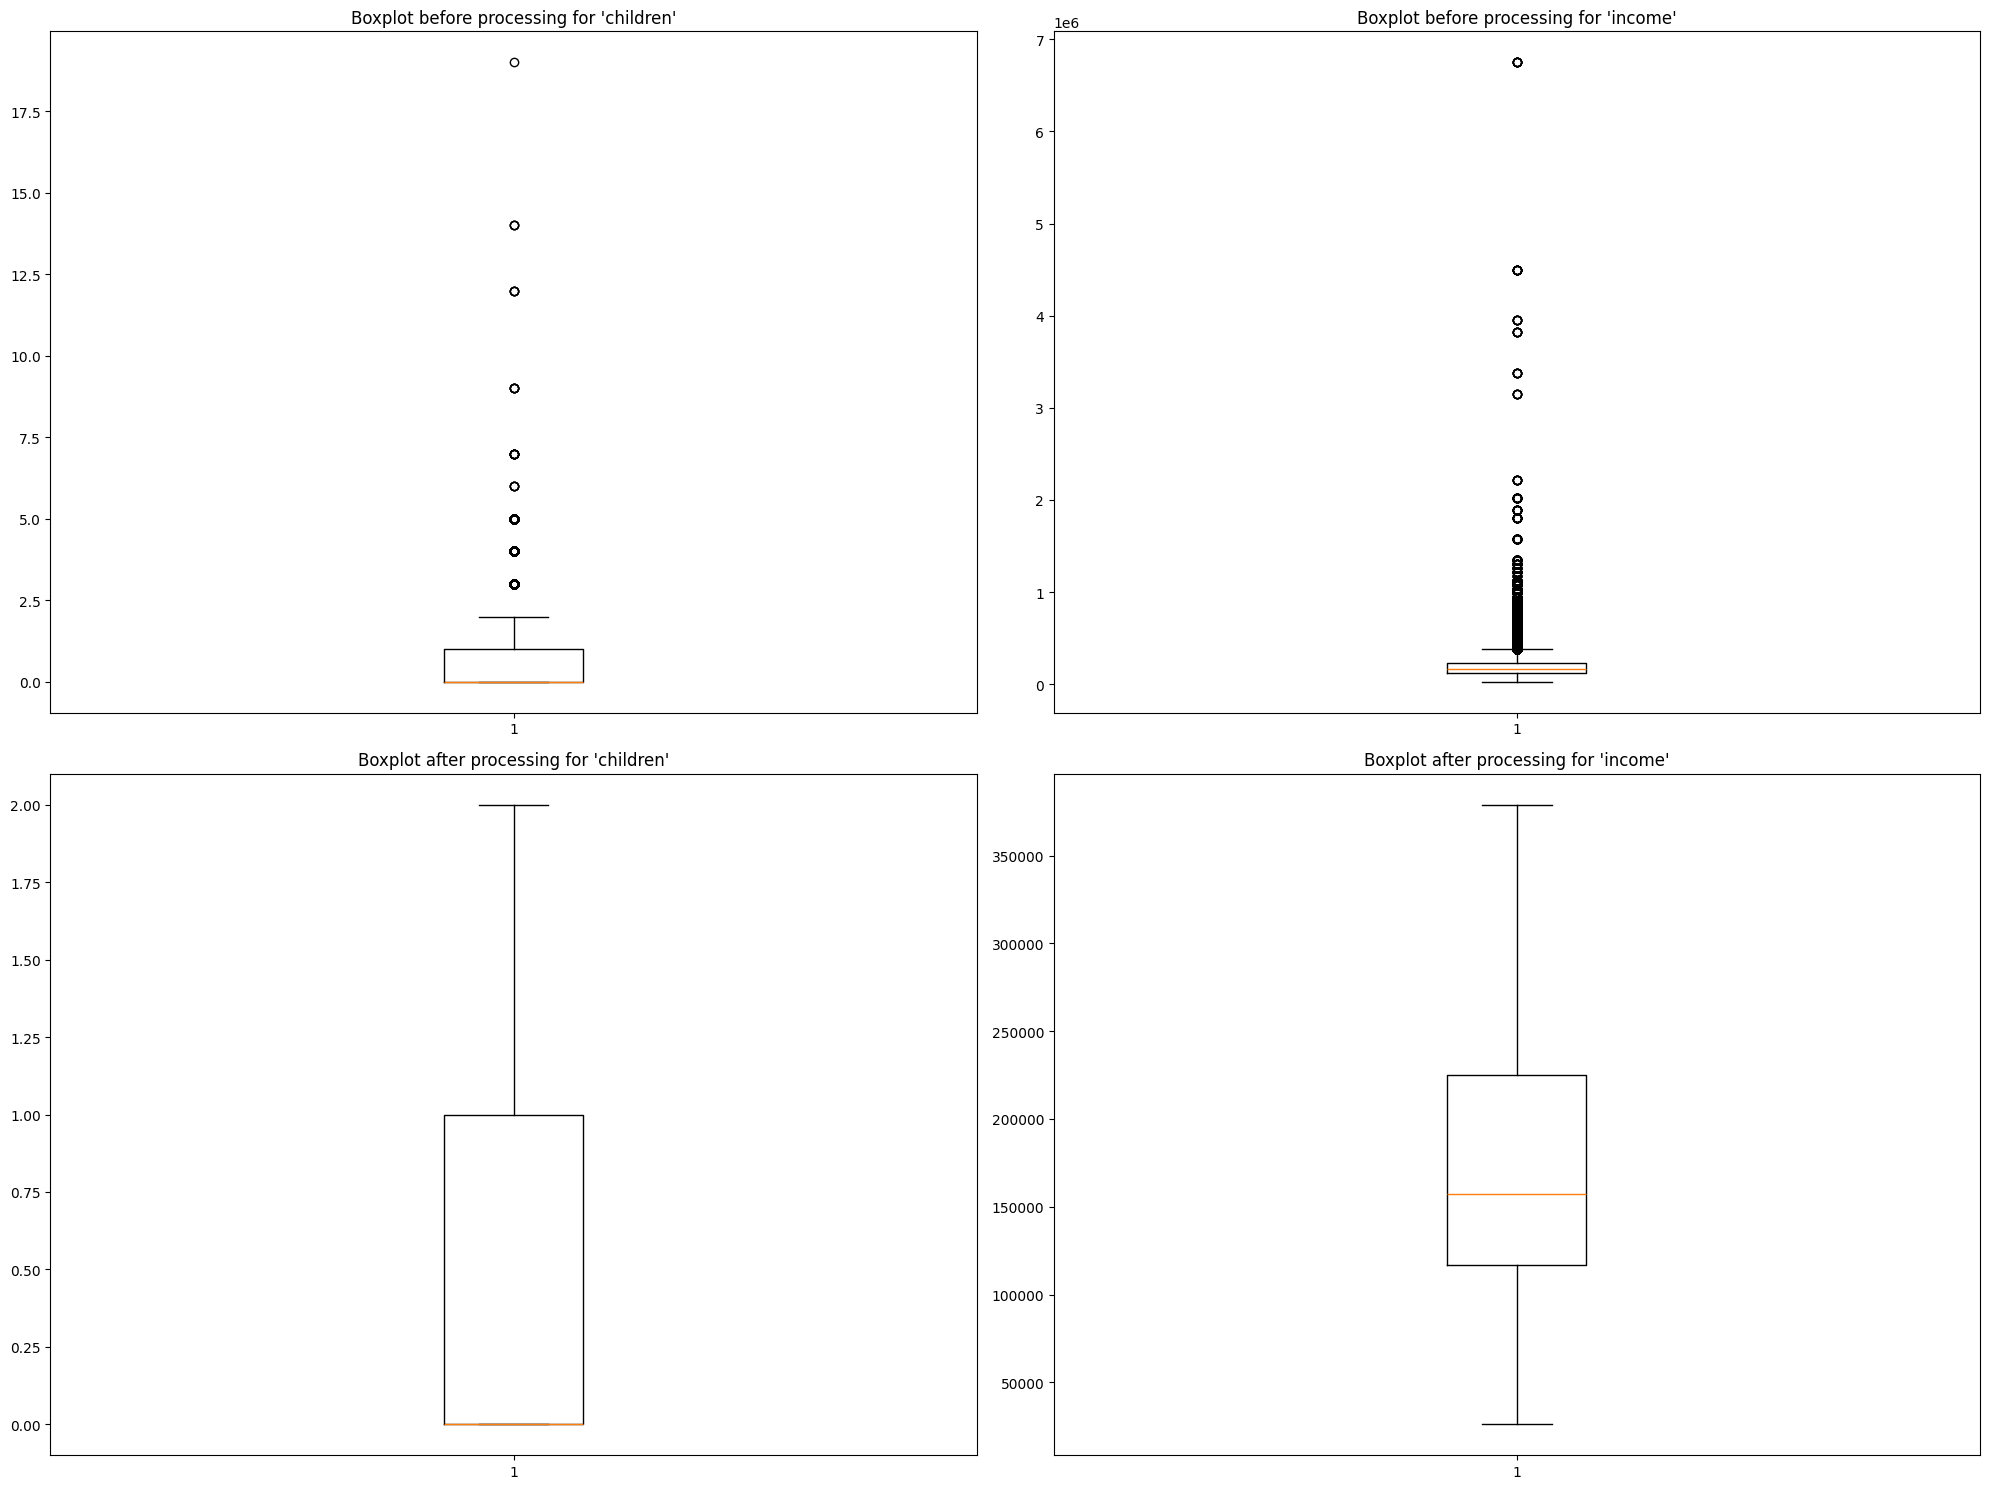

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

ax1, ax2, ax3, ax4 = axes.flatten()

ax1.boxplot(apps[col_children])
ax1.set_title("Boxplot before processing for 'children'")

ax2.boxplot(apps[col_income])
ax2.set_title("Boxplot before processing for 'income'")

ax3.boxplot(apps_removed_CI[col_children])
ax3.set_title("Boxplot after processing for 'children'")

ax4.boxplot(apps_removed_CI[col_income])
ax4.set_title("Boxplot after processing for 'income'")

plt.tight_layout()
plt.show()

### Preprocessing credit

We place clients in different risk zones

In [55]:
cred.rename(columns=rename_c, inplace=True)

cred = (
    cred.groupby('ID')['status']
    .agg(list)
    .reset_index()
)

cred['count_XC'] = cred['status'].apply(lambda x: sum(s in {'X', 'C'} for s in x))
cred['count_0']  = cred['status'].apply(lambda x: sum(s == '0' for s in x))
cred['count_1']  = cred['status'].apply(lambda x: sum(s == '1' for s in x))
cred['has_red']  = cred['status'].apply(lambda x: any(s in {'2','3','4','5'} for s in x))

cred['risk_zone'] = np.select(
    [
        cred['has_red'],
        (cred['count_XC'] > 1.5 * cred['count_0']) &
        (cred['count_XC'] > 2 * cred['count_1'])
    ],
    ['red', 'gray'],
    default='green'
)

cred = cred[['ID', 'risk_zone']]

In [56]:
cred

,ID,risk_zone
0,5001711,green
1,5001712,green
2,5001713,gray
3,5001714,gray
4,5001715,gray
...,...,...
45980,5150482,green
45981,5150483,gray
45982,5150484,green
45983,5150485,green


### Merge datasets

In [57]:
df = apps.merge(cred[["ID", "risk_zone"]], on="ID", how="inner")

In [58]:
df

,ID,gender,f_car,f_realty,cnt_children,total_income,income_type,education,family_status,housing,f_mobile,f_work_phone,f_phone,f_email,occupation,cnt_fam_members,age,employment_years,risk_zone
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Managers,0,32,12.4,gray
1,5008805,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Managers,0,32,12.4,gray
2,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,0,58,3.1,gray
3,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4,green
4,5008809,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,0,52,8.4,gray
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5150482,0,1,1,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Core staff,1,29,4.8,green
36453,5150483,0,1,1,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Core staff,1,29,4.8,gray
36454,5150484,0,1,1,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Core staff,1,29,4.8,green
36455,5150485,0,1,1,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Core staff,1,29,4.8,green


## Model Training

### CatBoost

### LightGBM

### XGBoost